
# Chapter 8



# Lab: Tree-Based Methods

- Involves stratifying or segmenting the predictor into simple regions with a certain set of splitting rules summarized into a tree.
- Easy interpretation.
- Not likely to overfit the data.
- Not good accuracy but can be enhanced by combining several trees via
  - Bagging
  - Random Forests
  - Boosting
  - Bayesian Additive Regression trees

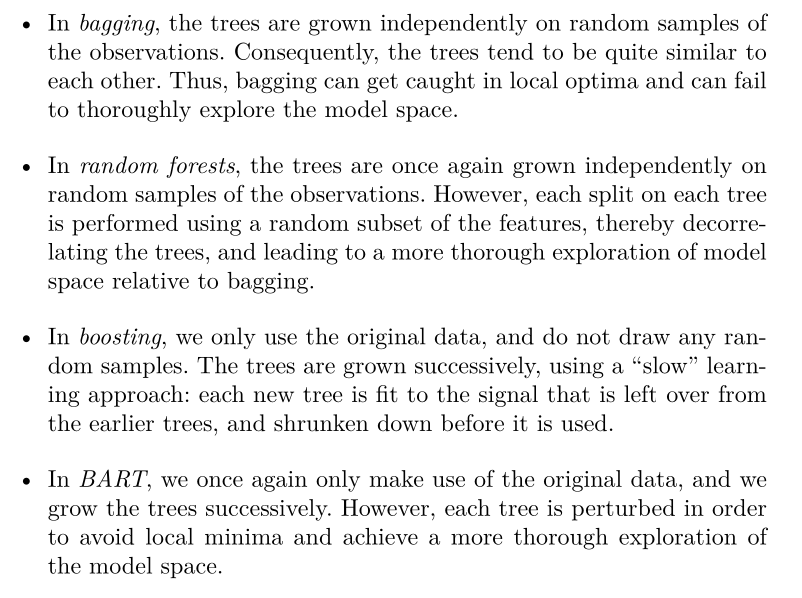

- Can be applied to regression and classification problems.
  - **Regression Trees**: Predicted values are the **mean responses of the samples on each region** (or _terminal nodes_ or _leaves_ of the tree), in opposition ot _internal nodes_.
       1. Divide the predictor space (set of possible values of $X_1, X_2..., X_p$) into $J$ distinct non-overlapping regions $R_1, R_2, ..., R_J$.
       2. For all predictions that fall into $R_j$ we make the same prediction: The mean of the response values for the training observations in $R_j$.
      - We must find boxes $R_1, ..., R_J$ thata minimizes the RSS, which is not easy to compute. Therefore, we use a greedy approach: **recursive binary splitting** for which, starting from a single region, **at each step the _best_ split is performed at that particular step of the tree-building**, on a top-down approach, without taking into account the best possible tree if steps ahead in the future could be analyzed. Each time two new regions are created, all regions (the previously existent and the newly created ones) are to be analyzed to find the best possible fit among all regions. That means all created regions are considered equal, nevermind the depth they hold in the tree. The process is repeated until a criteria (for example, that no regions contains more than 5 samples) is reached.
          - The best split is that for which the cutpoint $s$ is selected so that the greatest possible decrease in RSS is achieved (a predictor and cutpoint is selected at each step, as all possible cutpoints and predictor are compared). Two planes, $R_1(j,s) = \left\{ X | X_j < s \right\}$ and $R_2(j,s) = \left\{ X | X_j \geq s \right\}$ are formed so that the following expression is minimized, considering $\bar{y}_{R_j}$ the mean observation in each region:
           $$
            \sum_{i: x_i \in R_1(j,s)} (y_i - \bar{y}_{R_1})^2 + \sum_{i: x_i \in R_2(j,s)} (y_i - \bar{y}_{R_2})^2
           $$
        - Sometimes, **prunning** is performed: A deep wide tree $T_0$ is created and then pruned to obtain a subtree, the one with the lowest test error rate. Using cross-validation would be too cumbersome as there are many possible subtrees.
            - **Weakest link pruning**: We add a _cost_ $\alpha |T|$, with $alpha$ a tuning parameter (to be chosen via cross-validation) and $|T|$ the number of terminal nodes of the trees (representing tree size or the amount of regions the tree generates). We aim them to decrease the amount of regions along the RSS, similar to the Lasso regularization, which gets branches pruned in a predictable fashion.
               $$
              \sum_{m=1}^{|T|} \sum_{x_i \in R_m} (y_i - \bar{y_{R_m}})+\alpha |T|
               $$
              With this, we get a sequence of best subtrees as a function of $\alpha$.
  - **Classification trees** for qualitative responses. The prediction is that the **observation belongs to the most commonly ocurring class of training observations in the region** to which it belongs.
      - Criterions for making binary splits (instead of RSS)
          - The **classification error rate**: just the fraction of training observations that don't correspond to the most common class, $E=1-max_k(\hat{p}_{mk})$. This one is commonly used in prunning but not on the construction of $T_0$.
          - The **Gini index**, a measure of the total variance across all $K$ classes, or a way to measure _node purity_: $G=\sum_{k=1}^K \hat{p}_{mk}(1-\hat{p}_{mk})$.
          - The **Entropy**, which will also take a small value if the $m$th node is pure. $D=-\sum_{k=1}^{K} \hat{p}_{mk} \log(\hat{p}_{mk})$.

We import some of our usual libraries at this top
level.

In [37]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS

We also  collect the new imports
needed for this lab.

In [38]:
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          DecisionTreeRegressor as DTR,
                          plot_tree,
                          export_text)
from sklearn.metrics import (accuracy_score,
                             log_loss)
from sklearn.ensemble import \
     (RandomForestRegressor as RF,
      GradientBoostingRegressor as GBR)
from ISLP.bart import BART

## Fitting Classification Trees

We first use classification trees to analyze the  `Carseats`  data set.
In these data, `Sales` is a continuous variable, and so we begin
by recoding it as a binary variable. We use the `where()` 
function to create a variable, called `High`, which takes on a
value of `Yes` if the `Sales` variable exceeds 8, and takes
on a value of `No` otherwise.

In [39]:
Carseats = load_data('Carseats')
High = np.where(Carseats.Sales > 8, # Divide the carseats into high and low sales.
                "Yes",
                "No")


We now use `DecisionTreeClassifier()`  to fit a classification tree in
order to predict `High` using all variables but `Sales`.
To do so, we must form a model matrix as we did when fitting regression
models.  

In [40]:
model = MS(Carseats.columns.drop('Sales'), # We will use all columns except for sales, which is the variable to be predicted
            intercept=False) # We decide to go with no intercept. Why?
D = model.fit_transform(Carseats)
feature_names = list(D.columns)
X = np.asarray(D) # We want a numpy array with columns as features and rows as samples.

We have converted `D` from a data frame to an array `X`, which is needed in some of the analysis below. We also need the `feature_names` for annotating our plots later.

There are several options needed to specify the  classifier,
such as `max_depth` (how deep to grow the tree), `min_samples_split`
(minimum number of observations in a node to be eligible for splitting)
and `criterion` (whether to use Gini or cross-entropy as the split criterion).
We also set `random_state` for reproducibility; ties in the split criterion are broken at random.

In [41]:
# We create the tree creator by setting some variables
clf = DTC(criterion='entropy', # could have been gini
          max_depth=3, # how deep to grow the tree
          random_state=0) # for reproducibility
# And we fit the tree to the predictors and results from training data
clf.fit(X, High)


,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In our discussion of qualitative features in Section 3.3,
we noted that for a linear regression model such a feature could be
represented by including a matrix of dummy variables (one-hot-encoding) in the model
matrix, using the formula notation of `statsmodels`.
As mentioned in Section 8.1, there is a more
natural way to handle qualitative features when building a decision
tree, that does not require such dummy variables; each split amounts to partitioning the levels into two groups.
However, 
the `sklearn` implementation of decision trees does not take
advantage of this approach; instead it simply treats the one-hot-encoded levels as separate variables.

In [42]:
accuracy_score(High, clf.predict(X))


0.79

With only the default arguments, the training error rate is
21%.
For classification trees, we can
access the value of the deviance using `log_loss()`,
\begin{equation*}
\begin{split}
-2 \sum_m \sum_k n_{mk} \log \hat{p}_{mk},
\end{split}
\end{equation*}
where $n_{mk}$ is the number of observations in the $m$th terminal
node that belong to the $k$th class.

In [43]:
resid_dev = np.sum(log_loss(High, clf.predict_proba(X)))
resid_dev


np.float64(0.4710647062649358)

This is closely related to the *entropy*, defined in (8.7).
**A small deviance indicates a
tree that provides a good fit to the (training) data.**
 
One of the most attractive properties of trees is that they can
be graphically displayed. Here we use the `plot()`  function
to display the tree structure.

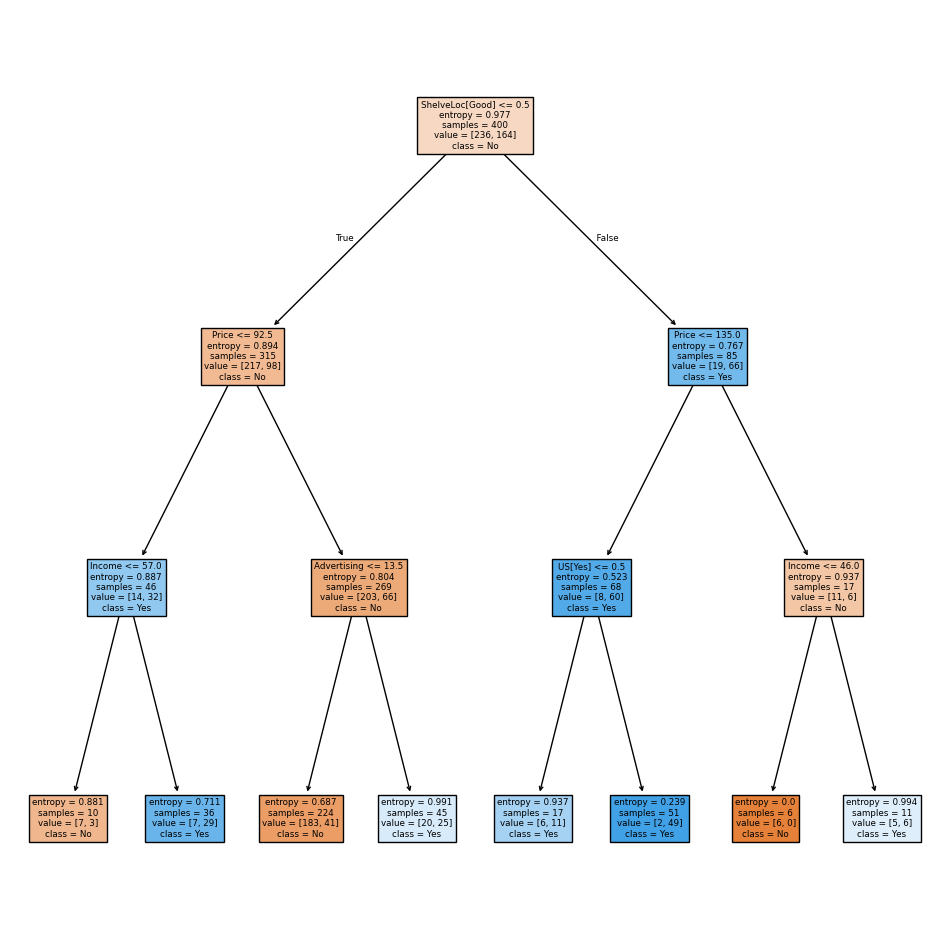

In [44]:
ax = subplots(figsize=(12,12))[1]
plot_tree(clf, # plot_tree comes with scikit_learn, and receives the fit clf.
          feature_names=feature_names, # As CLF required a numpy array, it knew nothing about the predictors names, so we have to let it know.
          class_names=['No', 'Yes'],
          filled=True,
          ax=ax);


The most important indicator of `Sales` appears to be `ShelveLoc`.

We can see a text representation of the tree using
`export_text()`, which displays the split
criterion (e.g. `Price <= 92.5`) for each branch.
For leaf nodes it shows the overall prediction  
(`Yes` or `No`). 
 We can also see the number of observations in that
leaf that take on values of `Yes` and `No` by specifying  `show_weights=True`.

In [45]:
print(export_text(clf,
                  feature_names=feature_names,
                  show_weights=True))


|--- ShelveLoc[Good] <= 0.50
|   |--- Price <= 92.50
|   |   |--- Income <= 57.00
|   |   |   |--- weights: [7.00, 3.00] class: No
|   |   |--- Income >  57.00
|   |   |   |--- weights: [7.00, 29.00] class: Yes
|   |--- Price >  92.50
|   |   |--- Advertising <= 13.50
|   |   |   |--- weights: [183.00, 41.00] class: No
|   |   |--- Advertising >  13.50
|   |   |   |--- weights: [20.00, 25.00] class: Yes
|--- ShelveLoc[Good] >  0.50
|   |--- Price <= 135.00
|   |   |--- US[Yes] <= 0.50
|   |   |   |--- weights: [6.00, 11.00] class: Yes
|   |   |--- US[Yes] >  0.50
|   |   |   |--- weights: [2.00, 49.00] class: Yes
|   |--- Price >  135.00
|   |   |--- Income <= 46.00
|   |   |   |--- weights: [6.00, 0.00] class: No
|   |   |--- Income >  46.00
|   |   |   |--- weights: [5.00, 6.00] class: Yes



### Using dtreeviz

/home/jovyan/.local/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


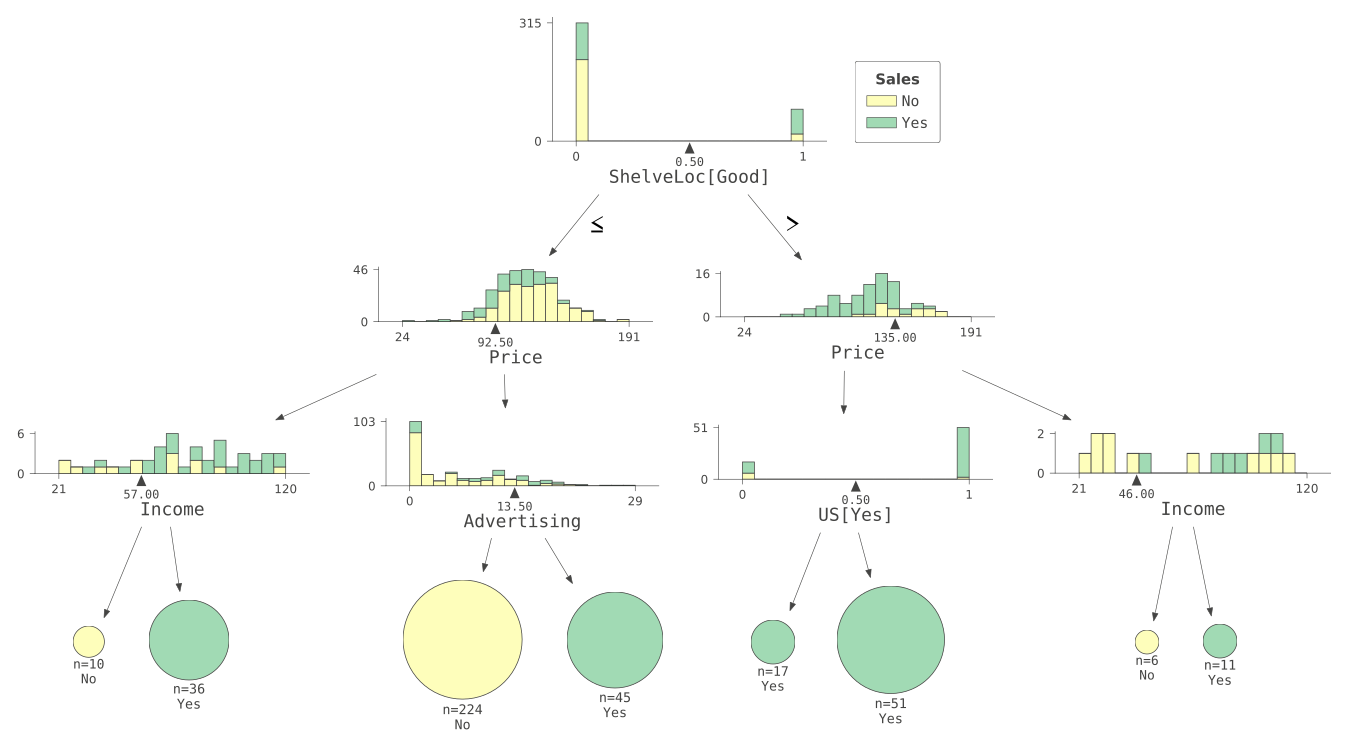

In [46]:
import dtreeviz
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'DejaVu Sans'  # This is usually available

High = np.where(Carseats.Sales > 8, # Divide the carseats into high and low sales.
                "Yes",
                "No")

model = MS(Carseats.columns.drop('Sales'), # We will use all columns except for sales, which is the variable to be predicted
            intercept=False) # We decide to go with no intercept. Why?
D = model.fit_transform(Carseats)
feature_names = list(D.columns)
X = np.asarray(D) # We want a numpy array with columns as features and rows as samples.

# If High contains string values like 'No', 'Yes'
le = LabelEncoder()
High_numeric = le.fit_transform(High)

# We create the tree creator by setting some variables
clf_numeric = DTC(criterion='entropy', # could have been gini
          max_depth=3, # how deep to grow the tree
          random_state=0) # for reproducibility
# And we fit the tree to the predictors and results from training data
clf_numeric.fit(D, High_numeric)

viz = dtreeviz.model(clf_numeric, D, High_numeric,
                target_name="Sales",
                feature_names=feature_names,
                class_names=['No', 'Yes'])
viz.view(fontname="monospace", scale=2)

In order to properly evaluate the performance of a classification tree
on these data, we must estimate the test error rather than simply
computing the training error. We split the observations into a
training set and a test set, build the tree using the training set,
and evaluate its performance on the test data. This pattern is
similar to that in Chapter 6, with the linear models
replaced here by decision trees --- the code for validation
is almost identical. This approach leads to correct predictions
for 68.5% of the locations in the test data set.

In [47]:
validation = skm.ShuffleSplit(n_splits=1,
                              test_size=200,
                              random_state=0)
results = skm.cross_validate(clf,
                             D,
                             High,
                             cv=validation) # inside the cross-validate the ShuffleSplit will be executed.
results['test_score']


array([0.685])

Next, we consider whether pruning the tree might lead to improved
classification performance. We first split the data into a training and
test set. We will use cross-validation to prune the tree on the training
set, and then evaluate the performance of the pruned tree on the test
set.

In [48]:
(X_train,
 X_test,
 High_train,
 High_test) = skm.train_test_split(X,
                                   High,
                                   test_size=0.5,
                                   random_state=0)
                                   

We first refit the full tree on the training set; here we do not set a `max_depth` parameter, since we will learn that through cross-validation.


In [49]:
clf = DTC(criterion='entropy', random_state=0) # Define the tree without setting a max_depth
clf.fit(X_train, High_train) # fit with the train data only
accuracy_score(High_test, clf.predict(X_test))  # And test on the test data


0.735

Next we use the `cost_complexity_pruning_path()` method of
`clf` to extract cost-complexity values. This method will calculate the alphas (the complexity parameters) for pruning, and for each alpha will determine the nodes that need to be pruned. It will then return a sequence of subtrees with decreasing complexity (as the alphas will be increasing). It returns `ccp_alphas` and `impurites` (the tree impurities).

With that sequence we can use cross-validation or pick manually the $\alpha$ to use to get the best results.


```mermaid
flowchart LR
tree[Define tree parameters with DTC] --> fit
train[Training data] -->|DTC| fit[Fit with training data] -->|ccpp| pruning[Pruning] --> alphas[alphas and pruned trees VECTOR] --> gridsearch[GridSearchCV] --> opt[Optimal alpha] --> fitopt[Fit]
train[Training data] --> pruning
train --> kfold[Kfold cross-validation] --> gridsearch
test[Test data]
```

In [50]:
ccp_path = clf.cost_complexity_pruning_path(X_train, High_train)
kfold = skm.KFold(10, # 10-fold cross validation
                  random_state=1,
                  shuffle=True)


This yields a set of impurities and $\alpha$ values
from which we can extract an optimal one by cross-validation.

In [51]:
grid = skm.GridSearchCV(clf, # the CLF will receive a certain alpha
                        {'ccp_alpha': ccp_path.ccp_alphas}, # the alphas over which to travel
                        refit=True,
                        cv=kfold,
                        scoring='accuracy') # the way to score
grid.fit(X_train, High_train)
grid.best_score_


np.float64(0.685)

Let’s take a look at the pruned true.

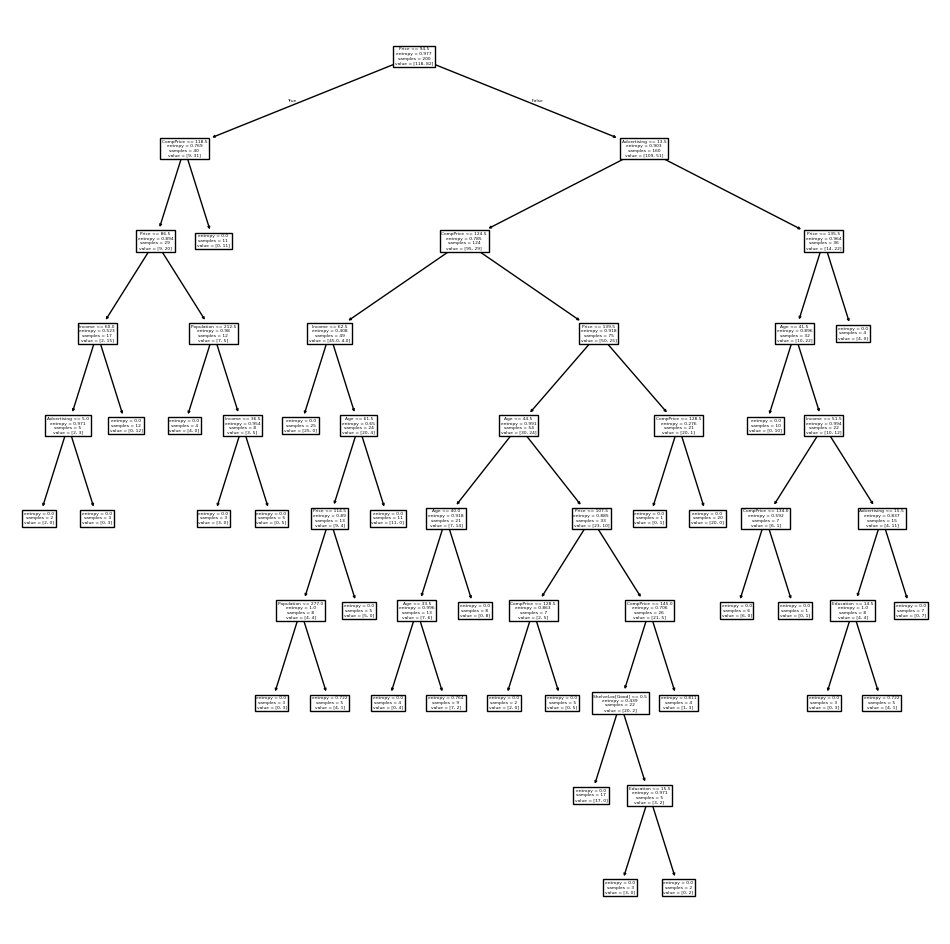

In [52]:
ax = subplots(figsize=(12, 12))[1]
best_ = grid.best_estimator_
plot_tree(best_,
          feature_names=feature_names,
          ax=ax);


This is quite a bushy tree. We could count the leaves, or query
`best_` instead.

In [53]:
best_.tree_.n_leaves


np.int64(30)

The tree with 30 terminal
nodes results in the lowest cross-validation error rate, with an accuracy of
68.5%. How well does this pruned tree perform on the test data set? Once
again, we apply the `predict()`  function.

In [54]:
print(accuracy_score(High_test,
                     best_.predict(X_test)))
confusion = confusion_table(best_.predict(X_test),
                            High_test)
confusion


0.72


Truth,No,Yes
Predicted,,
No,94,32
Yes,24,50


Now 72.0% of the test observations are correctly classified, which is slightly worse than the error for the full tree (with 35 leaves). So cross-validation has not helped us much here; it only pruned off 5 leaves, at a cost of a slightly worse error. These results would change if we were to change the random number seeds above; even though cross-validation gives an unbiased approach to model selection, it does have variance.

  

## Fitting Regression Trees
Here we fit a regression tree to the  `Boston`  data set. The
steps are similar to those for classification trees.

In [55]:
Boston = load_data("Boston")
model = MS(Boston.columns.drop('medv'), intercept=False) # the medv is the output to be predicted
D = model.fit_transform(Boston)
feature_names = list(D.columns)
X = np.asarray(D) # we want to use the numpy array version


First, we split the data into training and test sets, and fit the tree
to the training data. Here we use 30% of the data for the test set.


In [56]:
(X_train,
 X_test,
 y_train,
 y_test) = skm.train_test_split(X,   # a numpy array
                                Boston['medv'], # the output
                                test_size=0.3,
                                random_state=0)


Having formed  our training  and test data sets, we fit the regression tree.

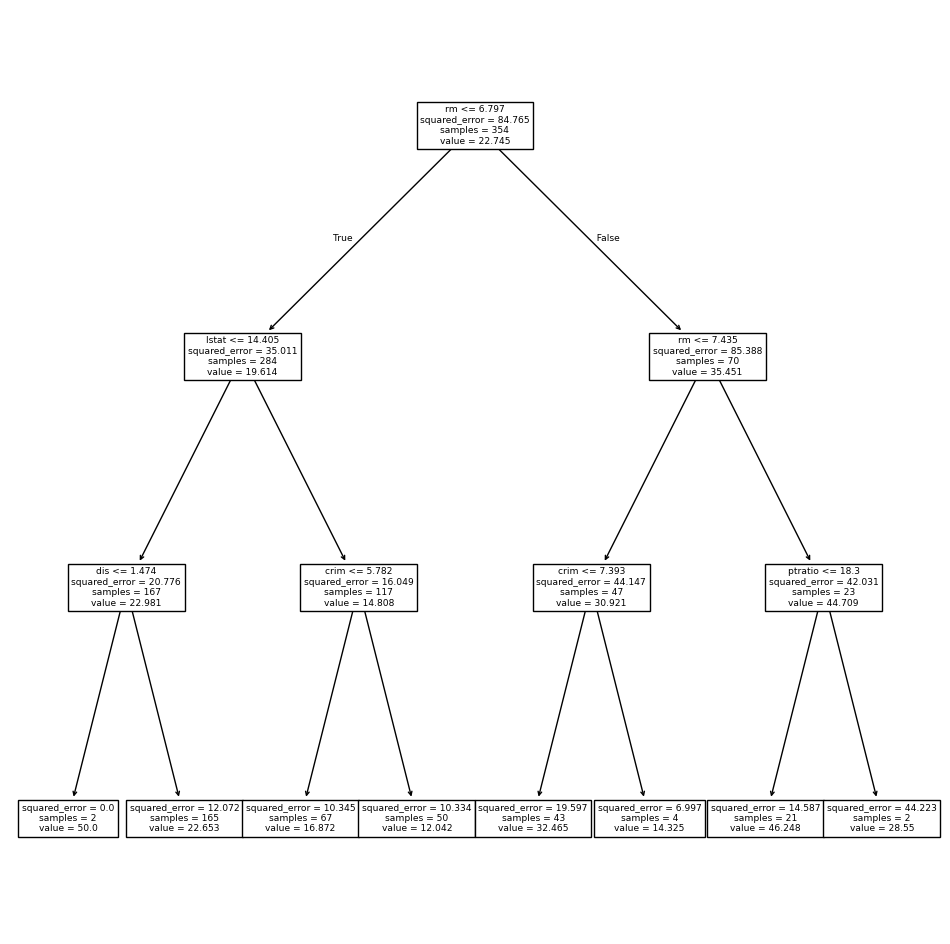

In [57]:
reg = DTR(max_depth=3) # a regression tree with up to 3 levels
reg.fit(X_train, y_train) # we use the training data to fit the tree
ax = subplots(figsize=(12,12))[1]
plot_tree(reg,
          feature_names=feature_names,
          ax=ax);


The variable `lstat` measures the percentage of individuals with
lower socioeconomic status. The tree indicates that lower
values of `lstat` correspond to more expensive houses.
The tree predicts a median house price of $12,042 for small-sized homes (`rm < 6.8`), in
suburbs in which residents have low socioeconomic status (`lstat  > 14.4`) and the crime-rate is moderate (`crim > 5.8`).

Now we use the cross-validation function to see whether pruning
the tree will improve performance.

In [58]:
ccp_path = reg.cost_complexity_pruning_path(X_train, y_train)
kfold = skm.KFold(5,
                  shuffle=True,
                  random_state=10)
grid = skm.GridSearchCV(reg,
                        {'ccp_alpha': ccp_path.ccp_alphas},
                        refit=True,
                        cv=kfold,
                        scoring='neg_mean_squared_error')
G = grid.fit(X_train, y_train)


In keeping with the cross-validation results, we use the pruned tree
to make predictions on the test set.

In [59]:
best_ = grid.best_estimator_
np.mean((y_test - best_.predict(X_test))**2)


np.float64(28.06985754975404)

In other words, the test set MSE associated with the regression tree
is 28.07.  The square root of
the MSE is therefore around
5.30,
indicating that this model leads to test predictions that are within around
$5300
of the true median home value for the suburb.

Let’s plot the best tree to see how interpretable it is.

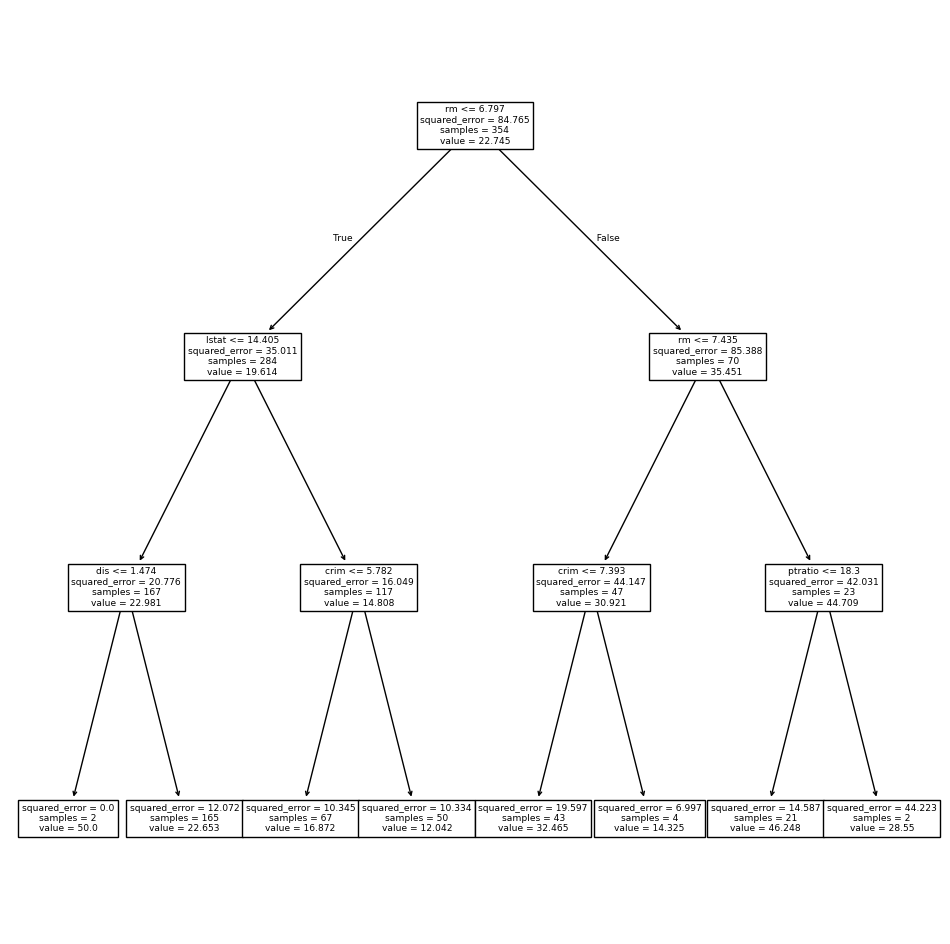

In [60]:
ax = subplots(figsize=(12,12))[1]
plot_tree(G.best_estimator_,
          feature_names=feature_names,
          ax=ax);


## Bagging and Random Forests

### Bagging

- Method to **reduce the variance of the trees**.
- The variance of the mean $\bar{Z}$ of the observations is given by $\sigma^2/n$, where $n$ is the amount of independent observations, and $\sigma$ is the variance of the observations --> **Averaging a set of observations reduces variance** or **the more observations we have, the more stable its mean**. Another way to look at it is that if we have $n$ observations, we will see a certain variance of the method, but if we perform the method several times on different samples or different training sets, and then average the results, we will have a lower variance on the results of the method. We could calculate $f^b(x)$, $b \in \[0,B\]$, with $B$ the amount of training sets, and **average them to obtain a single low variance statistical learning model**,

$$
\hat{f}_{avg}(x) = \frac{1}{B} \sum_{b=1}^B \hat{f}^b(x)
$$
The problem with this approach is that we do not have so many training sets, so we need to reuse them. Therefore, we **bootstrap: we take repeated samples from the single training data set**. We generate $B$ different bootstrapped training data sets. After using the method on the $B$ training sets obtained via bootstrapping, **we average the predictions**, which we call **bagging**.

- The trees to average out **are not pruned**.
- In the case of classifications, take the majority vote instead of averaging: The overall prediction is the most commonly ocurring class among the $B$ predictions.
- It's harder to interpret.

### Random forests
- improvement over bagged trees, by _decorrelating the trees_: It's executed like bagging, but each time a split is considered, a random sample of $m$ predictors is chosen as split candidates, and not the full set of $p$ predictors. A fresh sample of $m$ predictors is taken for each split, and in general $m=\sqrt{p}$, so only a minority of predictors can be used. This eliminates strong predictors that would otherwise be always selected by all the trees being averaged, which would make all the trees heavily correlated and therefore would have a lower impact on the decrease of variance.

Here we apply bagging and random forests to the `Boston` data, using
the `RandomForestRegressor()` from the `sklearn.ensemble` package. Recall
that **bagging is simply a special case of a random forest with
$m=p$. Therefore, the `RandomForestRegressor()`  function can be used to
perform both bagging and random forests**. We start with bagging.

In [61]:
bag_boston = RF(max_features=X_train.shape[1], random_state=0) # max_features = m = p so bagging and not random-forests.
bag_boston.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,12
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


The argument `max_features` indicates that all 12 predictors should
be considered for each split of the tree --- in other words, that
bagging should be done.  How well does this bagged model perform on
the test set?

np.float64(14.634700151315787)

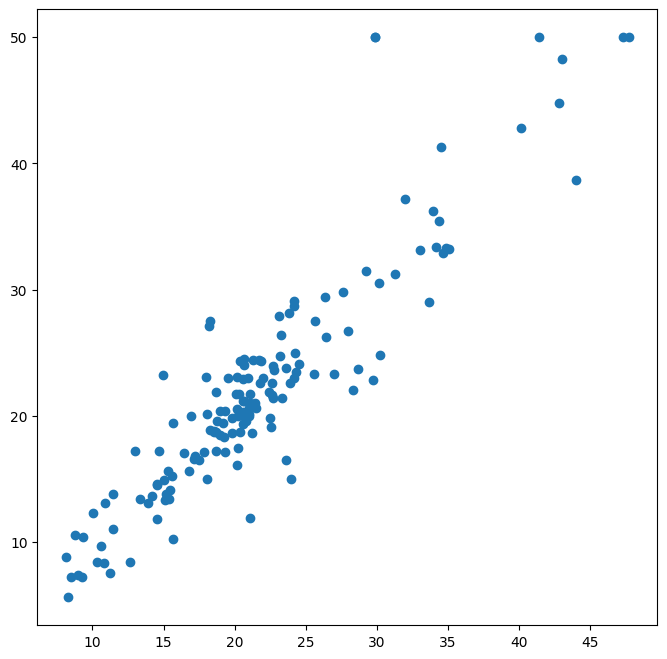

In [62]:
ax = subplots(figsize=(8,8))[1]
y_hat_bag = bag_boston.predict(X_test) # predict using the test
ax.scatter(y_hat_bag, y_test) # compare the predictions to the actual values
np.mean((y_test - y_hat_bag)**2) # calculate RSS


The test set MSE associated with the bagged regression tree is
14.63, about half that obtained using an optimally-pruned single
tree.  We could change the number of trees grown from the default of
100 by
using the `n_estimators` argument:

In [63]:
bag_boston = RF(max_features=X_train.shape[1],
                n_estimators=500, # amount of trees used
                random_state=0).fit(X_train, y_train)
y_hat_bag = bag_boston.predict(X_test)
np.mean((y_test - y_hat_bag)**2)

np.float64(14.605662565263161)

There is not much change. **Bagging and random forests cannot overfit by
increasing the number of trees, but can underfit if the number is too small.**

Growing a random forest proceeds in exactly the same way, except that
we use a smaller value of the `max_features` argument. By default,
`RandomForestRegressor()`  uses $p$ variables when building a random
forest of regression trees (i.e. it defaults to bagging), and `RandomForestClassifier()` uses
$\sqrt{p}$ variables when building a
random forest of classification trees. Here we use `max_features=6`.

In [64]:
RF_boston = RF(max_features=6,
               random_state=0).fit(X_train, y_train)
y_hat_RF = RF_boston.predict(X_test)
np.mean((y_test - y_hat_RF)**2)


np.float64(20.04276446710527)

The test set MSE is 20.04;
this indicates that random forests did somewhat worse than bagging
in this case. Extracting the `feature_importances_` values from the fitted model, we can view the
importance of each variable.

In [65]:
feature_imp = pd.DataFrame(
    {'importance':RF_boston.feature_importances_},
    index=feature_names)
feature_imp.sort_values(by='importance', ascending=False)

,importance
lstat,0.356203
rm,0.332163
ptratio,0.067270
crim,0.055404
indus,0.053851
dis,0.041582
nox,0.035225
tax,0.025355
age,0.021506
rad,0.004784


 This
is a relative measure of the total decrease in node impurity that results from
splits over that variable, averaged over all trees (this was plotted in Figure 8.9 for a model fit to the `Heart` data). 

The results indicate that across all of the trees considered in the
random forest, the wealth level of the community (`lstat`) and the
house size (`rm`) are by far the two most important variables.

  

## Boosting
- Similar to bagging but with trees grown sequentially, using information from previously grown trees.
- Does not use bootstrapping: **Each tree is fit on a modified version of the original dataset**: Given the current model, we fit a decision tree to the residuals from this model, instead of the outcome $Y$ as response. Then the new tree is added into the fitted function in order to update the residuals.
    - For each tree $b$, fit a tree with $d$ splits ($d+1$ terminal nodes), and then update the $\hat{f}$ by adding a shrunken version $\hat{f}(x) = \hat{f}_{prev}(x) + \lambda \hat{f}^b(x)$ and then update the residuals $r_i = r_i_{prev} - \lambda \hat{f}^b(x_i)$, and repeat for all the $B$ trees.
- The trees that are fit on the residuals can be small, depending on the parameter $d$.
- **Learns slowly**
- Depends on 3 parameters:
    - The number of trees $B$, because overfitting should be avoided.
    - The shrinkage parameter $\lambda$, which controls the learning rate. Typically 0.01 or 0.001.
    - The number $d$ of splits in each tree, controlling the complexity of the boosted ensemble. 

Here we use `GradientBoostingRegressor()` from `sklearn.ensemble`
to fit boosted regression trees to the `Boston` data
set. For classification we would  use `GradientBoostingClassifier()`.
The argument `n_estimators=5000`
indicates that we want 5000 trees, and the option
`max_depth=3` limits the depth of each tree. The
argument `learning_rate` is the $\lambda$
mentioned earlier in the description of boosting.

In [66]:
boost_boston = GBR(n_estimators=5000, # GradientBoostingRegression, with 5000 trees
                   learning_rate=0.001, # lambda
                   max_depth=3, # d
                   random_state=0)
boost_boston.fit(X_train, y_train) # we fit that on the train set


,loss,'squared_error'
,learning_rate,0.001
,n_estimators,5000
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


We can see how the training error decreases with the `train_score_` attribute.
To get an idea of how the test error decreases we can use the
`staged_predict()` method to get the predicted values along the path.

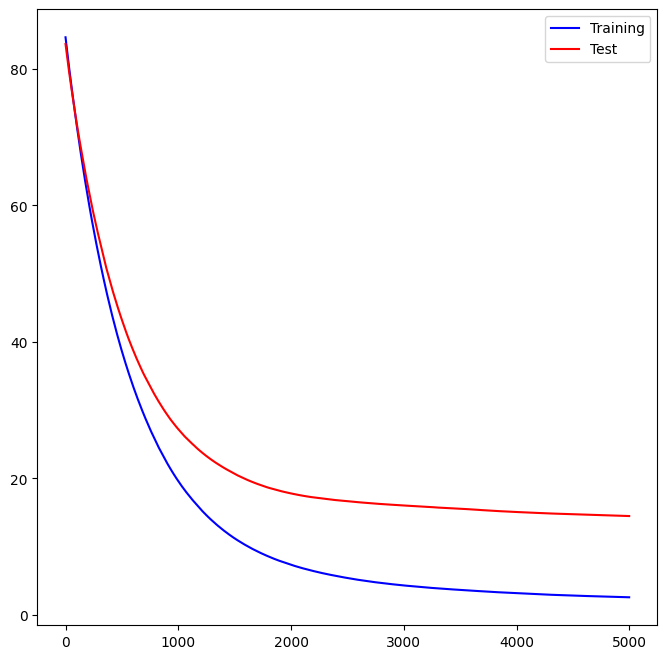

In [67]:
test_error = np.zeros_like(boost_boston.train_score_)
for idx, y_ in enumerate(boost_boston.staged_predict(X_test)):
   test_error[idx] = np.mean((y_test - y_)**2)

plot_idx = np.arange(boost_boston.train_score_.shape[0])
ax = subplots(figsize=(8,8))[1]
ax.plot(plot_idx,
        boost_boston.train_score_,
        'b',
        label='Training')
ax.plot(plot_idx,
        test_error,
        'r',
        label='Test')
ax.legend();


We now use the boosted model to predict `medv` on the test set:

In [68]:
y_hat_boost = boost_boston.predict(X_test);
np.mean((y_test - y_hat_boost)**2)


np.float64(14.481405918831591)

 The test MSE obtained is 14.48,
similar to the test MSE for bagging. If we want to, we can
perform boosting with a different value of the shrinkage parameter
$\lambda$ in  (8.10). The default value is 0.001, but
this is easily modified.  Here we take $\lambda=0.2$.

In [69]:
boost_boston = GBR(n_estimators=5000,
                   learning_rate=0.2,
                   max_depth=3,
                   random_state=0)
boost_boston.fit(X_train,
                 y_train)
y_hat_boost = boost_boston.predict(X_test);
np.mean((y_test - y_hat_boost)**2)


np.float64(14.501514553719565)

In this case, using $\lambda=0.2$ leads to a almost the same test MSE
as when using $\lambda=0.001$.

 

## Bayesian Additive Regression Trees
- Each tree is constructed as in bagging and random forests, randomly (as in bagging)
- But each tree is constructed so it captures the signal not yet accounted for by the current model (as in boosting).

---
Notation:
- $K$: Number of regression trees
- $B$: Number of iterations on which to run the algorithm.
- $\hat{f}_k^b(x)$: prediction at $x$, on the iteration $b$th, and in particular by the $k$th regression tree.
-
At the end of each $b$th iteration, the $K$ trees from that iteration will be summed:

$$
\hat{f}^b(x) = \sum_{k=1}^K \hat{f}_k^b(x) \text{ for } b=1,...,B
$$

The first iteration has all trees initialized to have a single root node: The mean of the response value, divided by the number of trees. Therefore, the end of the first iteration is no more than an average:
$$
f_k^1(x) = \frac{1}{nK}\sum_{i=1}^n y_i \qquad \therefore \qquad \hat{f}^1(x) = \sum_{k=1}^K \hat{f}^1_k(x) = \frac{1}{n} \sum_{i=1}^{n} y_i
$$

Following iterations update the $K$ trees, **one by one**, so that at the $b$th iteration, when updating the $k$th tree, the predictions from the rest of the trees (all but the $k$th tree) are substrated from the reponnse values (the $y$s in the training set), so that we get a *partial residual* for each sample. As we go one by one, we have to use the updated values (those form iteration $b$) on the trees up to the previous to the current one, and the values from the previous iteration $b-1$ on the trees not yet visited on this iteration.
$$
r_i = y_i - \sum_{k'<k} \hat{f}_{k'}^b(x_i) - \sum_{k'>k} \hat{f}_{k'}^{b-1}(x_i)
$$

*The new tree is not fit on this residuals*. **A random perturbation is chosen for the $k$th tree obtained in the previous iteration**, $\hat{g}^{b-1}_k$ to try to enhance the fit obtained in the previous iteration.
- Adding or pruning branches
- Change the prediction in each terminal node of the tree

So at the end we have a collection of predictions models as output for BART:
$$
\hat{f}^b(x) = \sum_{k=1}^K \hat{f}_k^b(x) \text{ for } b=1, 2, ..., B.
$$

- Throw away the first $L$ predictions, as they are part of a *burn in* period, and we average the remaining ones to get $f$.

$$
\hat{f} = \frac{1}{B-L} \sum_{b=L+1}^B \hat{f}^b(x)
$$

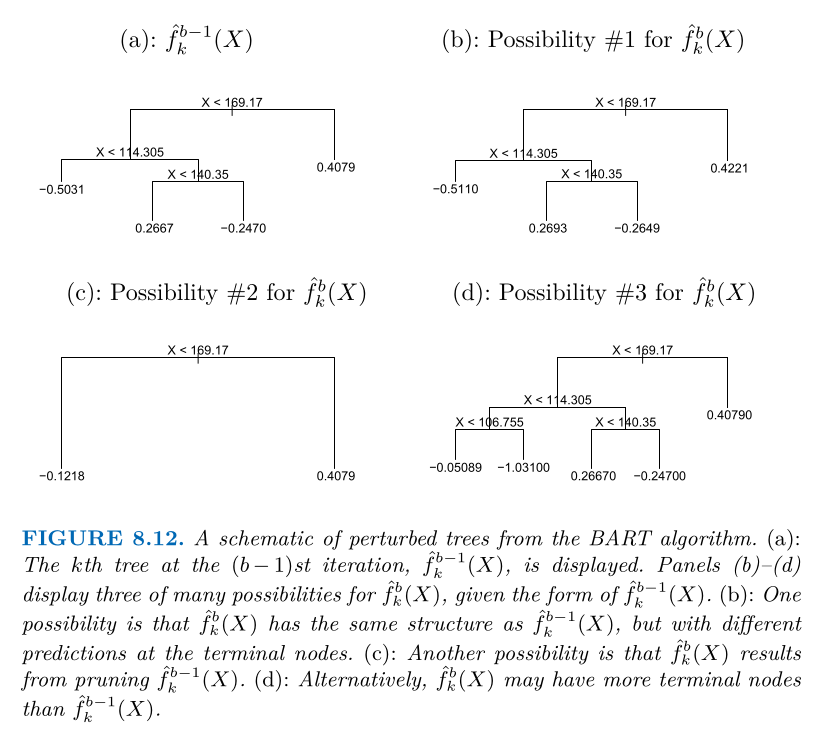

In this section we demonstrate a  `Python` implementation of BART found in the
`ISLP.bart` package. We fit a  model
to the `Boston` housing data set. This `BART()` estimator is
designed for quantitative outcome variables, though other implementations are available for
fitting logistic and probit models to categorical outcomes.

In [70]:
bart_boston = BART(random_state=0, burnin=5, ndraw=15)
bart_boston.fit(X_train, y_train)

,num_trees,200
,num_particles,10
,max_stages,5000
,split_prob,<function BAR...x76433d2baca0>
,min_depth,0
,std_scale,2
,split_prior,None
,ndraw,15
,burnin,5
,sigma_prior,"(5, ...)"
,num_quantile,50


On this data set, with this split into test and training, we see that the test error of BART is similar to that of  random forest.

In [71]:
yhat_test = bart_boston.predict(X_test.astype(np.float32))
np.mean((y_test - yhat_test)**2)


np.float64(22.145009458109225)

We can check how many times each variable appeared in the collection of trees.
This gives a summary similar to the variable importance plot for boosting and random forests.

In [72]:
var_inclusion = pd.Series(bart_boston.variable_inclusion_.mean(0),
                               index=D.columns)
var_inclusion


crim       26.933333
zn         27.866667
indus      26.466667
chas       22.466667
nox        26.600000
rm         29.800000
age        22.733333
dis        26.466667
rad        23.666667
tax        24.133333
ptratio    24.266667
lstat      31.000000
dtype: float64